In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import rasterio

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.12.1+cu130
CUDA: True
Device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


In [2]:
ms_train = "../data/EuroSATallBands/train"
ms_val = "../data/EuroSATallBands/val"

print(os.path.exists(ms_train))
print(os.path.exists(ms_val))

print(os.listdir(ms_train))

True
True
['Residential', 'PermanentCrop', 'HerbaceousVegetation', 'Highway', 'SeaLake', 'Pasture', 'Industrial', 'AnnualCrop', 'Forest', 'River']


In [3]:
class_name = os.listdir(ms_train)[0]

sample_file = os.path.join(
    ms_train,
    class_name,
    os.listdir(os.path.join(ms_train, class_name))[0]
)

print(sample_file)

../data/EuroSATallBands/train/Residential/Residential_270.tif


In [4]:
import torch
from torch.utils.data import Dataset
import rasterio
import os

class EuroSATMultiDataset(Dataset):

    def __init__(self, root_dir):

        self.samples = []

        self.classes = sorted(os.listdir(root_dir))

        self.class_to_idx = {
            cls: idx
            for idx, cls in enumerate(self.classes)
        }

        for cls in self.classes:

            cls_path = os.path.join(root_dir, cls)

            for file in os.listdir(cls_path):

                if file.endswith(".tif"):

                    self.samples.append(
                        (
                            os.path.join(cls_path, file),
                            self.class_to_idx[cls]
                        )
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        file_path, label = self.samples[idx]

        with rasterio.open(file_path) as src:
            image = src.read()

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        return image, label

In [5]:
train_dataset = EuroSATMultiDataset(ms_train)
val_dataset = EuroSATMultiDataset(ms_val)

print(len(train_dataset))
print(len(val_dataset))
print(train_dataset.classes)

18900
4050
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([13, 64, 64])
0


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
)

print("Loaders created")

Loaders created


In [8]:
import torch.nn as nn

class MultiSpectralCNN(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(13, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, num_classes)

        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

In [9]:
model = MultiSpectralCNN(num_classes=10)

model = model.to(device)

print(model)

MultiSpectralCNN(
  (features): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [10]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 10])


In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [13]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [14]:
epochs = 10

best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "../models/multispectral_best.pth"
        )

        print("Best model saved")


Epoch 1/10
Train Loss: 2.0629 | Train Acc: 60.18%
Val Loss: 0.6899 | Val Acc: 76.67%
Best model saved

Epoch 2/10
Train Loss: 0.6637 | Train Acc: 77.42%
Val Loss: 0.4106 | Val Acc: 86.44%
Best model saved

Epoch 3/10
Train Loss: 0.5115 | Train Acc: 82.91%
Val Loss: 0.3876 | Val Acc: 87.51%
Best model saved

Epoch 4/10
Train Loss: 0.3975 | Train Acc: 86.52%
Val Loss: 0.3389 | Val Acc: 88.79%
Best model saved

Epoch 5/10
Train Loss: 0.3314 | Train Acc: 88.93%
Val Loss: 0.2788 | Val Acc: 90.72%
Best model saved

Epoch 6/10
Train Loss: 0.2709 | Train Acc: 90.83%
Val Loss: 0.2962 | Val Acc: 90.32%

Epoch 7/10
Train Loss: 0.2384 | Train Acc: 91.96%
Val Loss: 0.3806 | Val Acc: 88.02%

Epoch 8/10
Train Loss: 0.2074 | Train Acc: 92.96%
Val Loss: 0.3531 | Val Acc: 89.65%

Epoch 9/10
Train Loss: 0.1714 | Train Acc: 94.29%
Val Loss: 0.2542 | Val Acc: 92.35%
Best model saved

Epoch 10/10
Train Loss: 0.1494 | Train Acc: 95.02%
Val Loss: 0.2385 | Val Acc: 92.99%
Best model saved


In [15]:
print(train_dataset.classes)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [16]:
print(train_dataset[0][0].shape)
print(train_dataset[0][0].min())
print(train_dataset[0][0].max())

torch.Size([13, 64, 64])
tensor(13.)
tensor(5664.)


In [17]:
print(val_dataset[0][0].min())
print(val_dataset[0][0].max())

import rasterio

sample_path = val_dataset.samples[0][0]

with rasterio.open(sample_path) as src:
    raw = src.read()

print(raw.min())
print(raw.max())

tensor(11.)
tensor(5413.)
11
5413


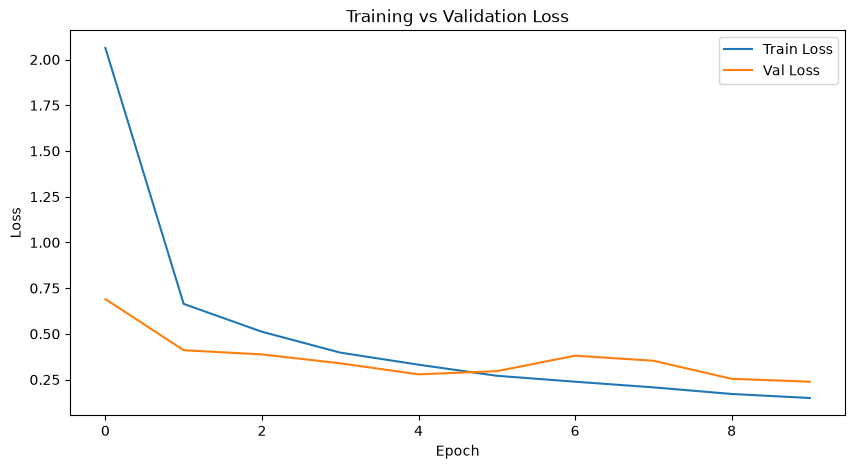

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title("Training vs Validation Loss")

plt.savefig("loss_curve.png")

plt.show()

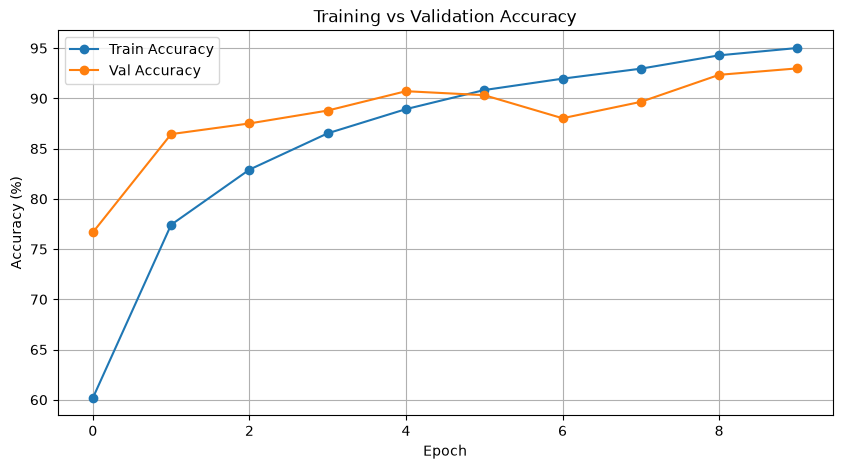

In [19]:
plt.figure(figsize=(10,5))

plt.plot(train_accs, marker="o", label="Train Accuracy")
plt.plot(val_accs, marker="o", label="Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.savefig("accuracy_curve.png")

plt.show()

In [20]:
import os

for f in os.listdir():
    if f.endswith(".png") or f.endswith(".txt"):
        print(f)

loss_curve.png
confusion_matrix.png
accuracy_curve.png
classification_report.txt


In [21]:
import os

print(os.path.exists("../models/multispectral_best.pth"))


True


In [22]:
print(train_loader.batch_size)

32


In [23]:
print(model)

MultiSpectralCNN(
  (features): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [24]:
print(model.conv1)

AttributeError: 'MultiSpectralCNN' object has no attribute 'conv1'